Phase 1: Data Preparation

1.1 Cleaning the Dataset

In [1]:
import pandas as pd

# Read dataset'
df = pd.read_csv("google_traffic_data_v2.csv")
df.head()

,timestamp,route,distance_km,hour,day,day_of_week,travel_time_mins,speed_kmh,congestion,weather_condition,rainfall_status,holiday_indicator,school_holiday_indicator,school_hours_indicator,working_hours_indicator,office_rush_hour_indicator,event_indicator,event_type,event_severity,traffic_pressure_score
0,2026-05-07 13:41:47,Bonduma Gate to Mile 17,3.81,13,Thursday,3,10.90,20.99,Low,Clouds,No Rain,0,0,1,1,0,0,NaN,Low,25
1,2026-05-07 13:41:47,Mile 17 to Malingo,1.54,13,Thursday,3,4.95,18.70,Low,Clouds,No Rain,0,0,1,1,0,0,NaN,Low,25
2,2026-05-07 13:41:47,Malingo to UB Junction,3.47,13,Thursday,3,11.77,17.69,Low,Clouds,No Rain,0,0,1,1,0,0,NaN,Low,25
3,2026-05-07 13:41:47,UB Junction to Check Point,2.15,13,Thursday,3,9.20,14.05,Low,Clouds,No Rain,0,0,1,1,0,0,NaN,Low,25
4,2026-05-07 13:41:47,Check Point to Buea Town,3.12,13,Thursday,3,8.03,23.32,Low,Clouds,No Rain,0,0,1,1,0,0,NaN,Low,25


In [2]:
df.shape

(10974, 20)

In [3]:
# Remove duplicates
df = df.drop_duplicates()

# Logical consistency: Speed cannot be negative, Travel Time > 0
df = df[(df['speed_kmh'] > 0) & (df['travel_time_mins'] > 0)]

# Ensure timestamp is in datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [4]:
# Numerical: Fill with median to avoid outlier influence
# Convert column to numeric
df['traffic_pressure_score'] = pd.to_numeric(
    df['traffic_pressure_score'],
    errors='coerce'
)

df['traffic_pressure_score'] = df['traffic_pressure_score'].fillna(df['traffic_pressure_score'].median())

# Categorical: Fill with 'None' if appropriate
df['event_type'] = df['event_type'].fillna('None')

df.shape


(10316, 20)

1.3 Encoding Categorical Features

In [5]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding for ordinal data (e.g, Severity)
le = LabelEncoder()
df['event_severity'] = le.fit_transform(df['event_severity'])

# 1.4 Feature Engineering

# Time-based features
df['is_weekend'] = df['timestamp'].dt.dayofweek.isin([5, 6]).astype(int)
df['is_morning_rush'] = df['hour'].apply(lambda x: 1 if 7 <= x <= 9 else 0)

# Lag Features: Traffic state 1 hour ago
df = df.sort_values('timestamp')
df['prev_hour_speed'] = df.groupby('route')['speed_kmh'].shift(1)
df['prev_hour_speed'] = df['prev_hour_speed'].fillna(df['speed_kmh'])

# Encoding Categorical Features

# One-Hot Encoding for nominal data
df = pd.get_dummies(
    df, columns=[
        'route',
        'weather_condition',
        'rainfall_status',
        'event_type',
    ], drop_first=True
)
df.head()

,timestamp,distance_km,hour,day,day_of_week,travel_time_mins,speed_kmh,congestion,holiday_indicator,school_holiday_indicator,...,route_UB Junction to Bonduma,route_UB Junction to Buea Town,route_UB Junction to Check Point,route_UB Junction to Great Soppo,route_UB Junction to Molyko,route_UB Junction to Muea,weather_condition_Rain,rainfall_status_Rain,event_type_Market Activity,event_type_None
0,2026-05-07 13:41:47,3.81,13,Thursday,3,10.90,20.99,Low,0,0,...,False,False,False,False,False,False,False,False,False,True
21,2026-05-07 13:41:47,2.12,13,Thursday,3,5.53,23.03,Low,0,0,...,False,False,False,False,False,False,False,False,False,True
20,2026-05-07 13:41:47,5.04,13,Thursday,3,14.65,20.66,Low,0,0,...,False,False,False,False,False,False,False,False,False,True
19,2026-05-07 13:41:47,2.06,13,Thursday,3,6.18,20.00,Low,0,0,...,False,False,False,False,False,False,False,False,False,True
18,2026-05-07 13:41:47,4.17,13,Thursday,3,11.68,21.43,Low,0,0,...,False,False,False,False,False,False,False,False,False,True


In [6]:
# Check data types to ensure no present object data type
print(df.dtypes.value_counts())

bool              67
int64             11
float64            5
str                2
datetime64[us]     1
Name: count, dtype: int64


1.5 Data Splitting (Time-series)

In [7]:
from sklearn.model_selection import TimeSeriesSplit

# Sort by time before splitting
df = df.sort_values('timestamp')

# Define features (X) and target (y)
X = df.drop(['congestion', 'timestamp', 'speed_kmh','travel_time_mins'], axis = 1)
y = df['congestion']

# TimeSeriesSplit prevents data leakage from the future
tscv = TimeSeriesSplit(n_splits=5)
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

Phase 2: Exploratory Data Analysis (EDA)

2.1 Visualizations

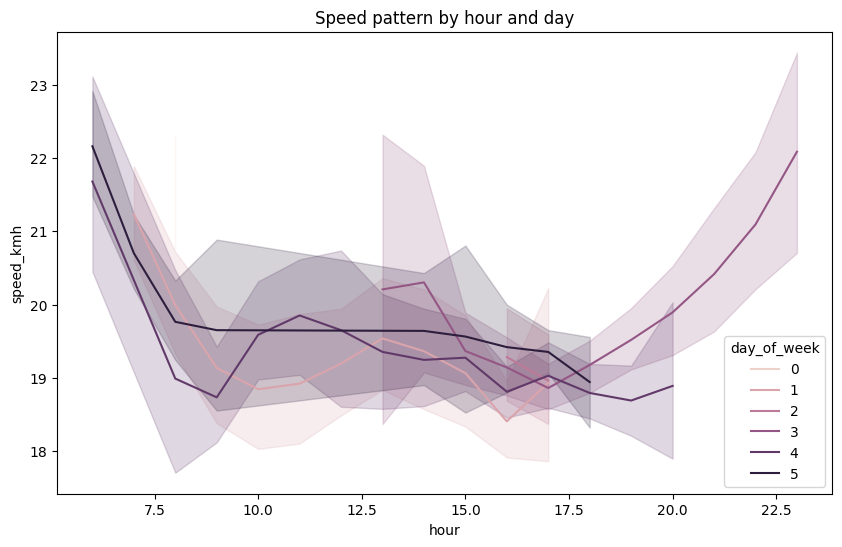

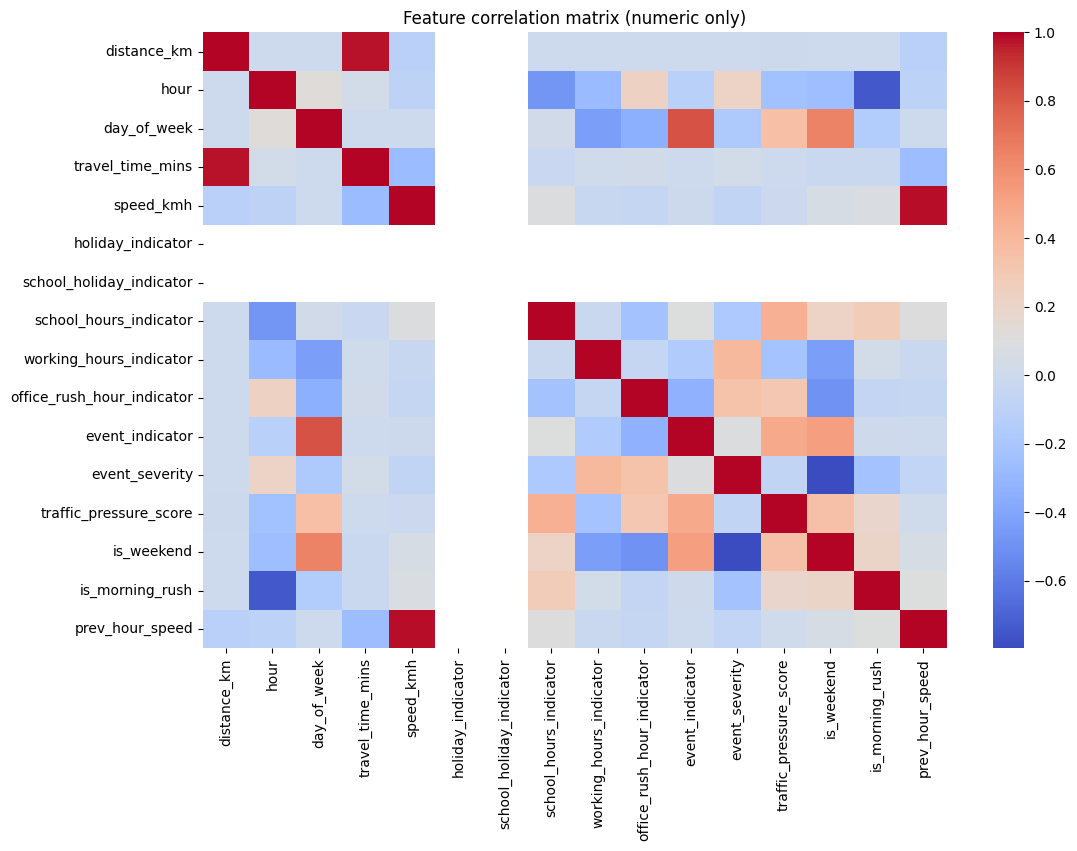

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Traffic patter by hour
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='hour', y='speed_kmh', hue='day_of_week')
plt.title("Speed pattern by hour and day")
plt.show()

# Heatmap of correlation
plt.figure(figsize=(12, 8))

# Filter for numeric columns only before calling .corr()
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title("Feature correlation matrix (numeric only)")
plt.show()

2.2 Outlier Detection

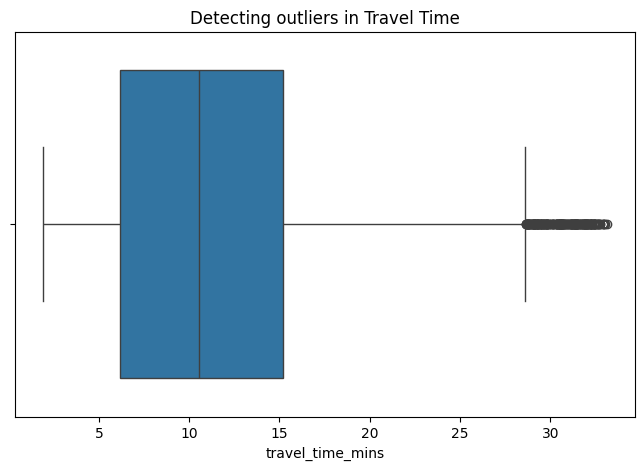

In [9]:
# Using Boxplots to find extreme 'Travel Time' values
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['travel_time_mins'])
plt.title('Detecting outliers in Travel Time')
plt.show()

Phase 3: Training with XGBoost

3.1 Preparing data for XGBoost

In [10]:
df.dtypes

timestamp                     datetime64[us]
distance_km                          float64
hour                                   int64
day                                      str
day_of_week                            int64
                                   ...      
route_UB Junction to Muea               bool
weather_condition_Rain                  bool
rainfall_status_Rain                    bool
event_type_Market Activity              bool
event_type_None                         bool
Length: 86, dtype: object

In [11]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit

# Convert invalid cols to category dtype
if 'day' in df.columns:
      df['day'] = df['day'].astype('category')

# Convert low, medium, high to 0,1,2
le_target = LabelEncoder()
df['congestion_encoded'] = le_target.fit_transform(df['congestion'])

print("Remaining text columns:",df.select_dtypes(include=['object']).columns.tolist())

Remaining text columns: ['congestion']


/tmp/ipykernel_49947/2843182605.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Remaining text columns:",df.select_dtypes(include=['object']).columns.tolist())


In [12]:
# Define features (X) and target (y)
# Drop non-numeric 'congestion' and 'timestamp' before training
cols_to_drop = ['congestion', 'congestion_encoded', 'timestamp', 'speed_kmh','travel_time_mins', 'traffic_pressure_score']
existing_drops = [c for c in cols_to_drop if c in df.columns]

X = df.drop(existing_drops, axis = 1)
y = df['congestion_encoded']

tscv = TimeSeriesSplit(n_splits=5)
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

print("Final dtypes in X_train:")
print(X_train.dtypes.value_counts())


# Splitting logic (Mental check: Ensure it's chronological)
# Assuming X_train, X_test, y_train, y_test are already created from phase 1.5

dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)

print("DMatrix created successfully!")

Final dtypes in X_train:
bool        67
int64       11
float64      2
category     1
Name: count, dtype: int64
DMatrix created successfully!


In [13]:
# Set the parameters
params = {
    'max_depth': 6, # How deep each tree can grow
    'eta': 0.1, # Learning rate (how fast the model learns)
    'objective': 'multi:softmax', # The task: multiclass classification
    'num_class': 3, # Number of congestion levels (low, medium, high)
    'eval_metric': 'mlogloss' # How the model measures its own error
}

# Train the model
# evals: tells XGBoost to watch the test set while training
# early_stopping_rounds: stop training if the test error doesn't improve for 10 rounds

model_xgb = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dtest, "Test")],
    early_stopping_rounds=10,
    verbose_eval=50
)

[0]	Test-mlogloss:0.22623
[50]	Test-mlogloss:0.12045
[100]	Test-mlogloss:0.10982
[150]	Test-mlogloss:0.10614
[161]	Test-mlogloss:0.10625


3.3 Saving the model

In [14]:
import joblib
model_xgb.save_model('traffic_xgb_model.json')
joblib.dump(model_xgb, 'model_XGBoost.pkl')
print("XGBoost model trained and saved")

XGBoost model trained and saved


Phase 4: Training with LightGBM

4.1 LightGBM dataset

In [15]:
import lightgbm as lgb
_
# Prepare LightGBM datasets
# Will use the same X_train and y_train above
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_test = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

# Set parameters
lgb_params = {
    'boosting_type': 'gbdt', # Standard gradient boosting
    'objective': 'multiclass', # Same task as XGBoost
    'num_class': 3,
    'metric': 'multi_logloss',
    'num_leaves': 31, # Controls model complexity
    'learning_rate': 0.05
}

4.2 Training Workflow

In [16]:
model_lgb = lgb.train(
    lgb_params,
    lgb_train,
    valid_sets=[lgb_test],
    num_boost_round=500,
    callbacks=[lgb.early_stopping(stopping_rounds=10)]
)
print("LightGBM model trained")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033257 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 481
[LightGBM] [Info] Number of data points in the train set: 8597, number of used features: 76
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score -6.979727
[LightGBM] [Info] Start training from score -0.043020
[LightGBM] [Info] Start training from score -3.189872
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[100]	valid_0's multi_logloss: 0.0966784
LightGBM model trained


--- Classification Report (LightGBM)---
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         0
         Low       0.97      0.99      0.98      1602
      Medium       0.76      0.60      0.67       117

    accuracy                           0.96      1719
   macro avg       0.58      0.53      0.55      1719
weighted avg       0.96      0.96      0.96      1719



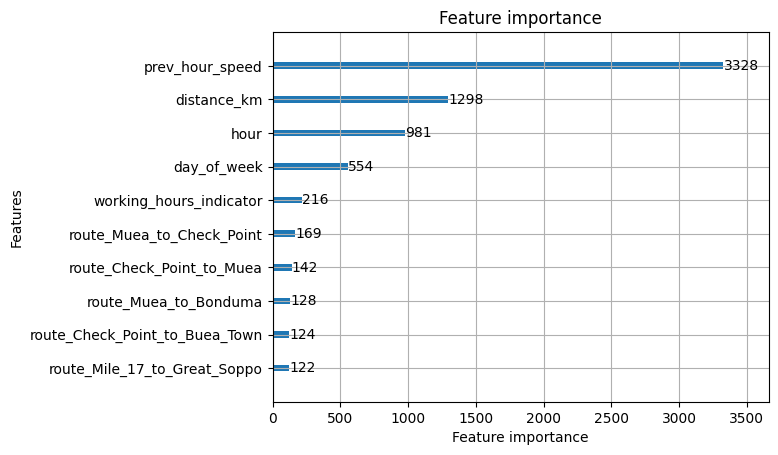

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions from LightGBM
# LightGBM returns probabilities, so we use argmax to get the class with highest probability
preds_prob = model_lgb.predict(X_test)
y_pred = [np.argmax(x) for x in preds_prob]

# Identify the unique numeric codes for your classes
# (e.g., [0, 1, 2])
class_indices = list(range(len(le_target.classes_)))

# Print report
# Uses the LabelEncoder from earlier to show "Low", "Medium", etc.

print("--- Classification Report (LightGBM)---")

# We add 'labels=class_indices' to tell the report to look for all 3 classes
# even if one (like 'Low') is missing from the target.'
print(classification_report(
    y_test,
    y_pred,
    labels=class_indices,
    target_names=le_target.classes_,
    zero_division=0
)) # This prevents errors if a class has 0 samples

# Feature importance
lgb.plot_importance(model_lgb, max_num_features=10)
plt.show()

In [18]:
import joblib

joblib.dump(le_target, 'label_encoder.pkl')

joblib.dump(model_lgb, 'traffic_model.pkl')

['traffic_model.pkl']

Comparing XGBoost vs. LightGBM

In [19]:
from sklearn.metrics import accuracy_score, f1_score
import time

# --- Evaluate XGBoost ---
# XGBoost uses softmax, so we get the class directly
y_pred_xgb = model_xgb.predict(dtest)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

# --- Evaluate LightGBM ---
# LightGBM gives probabilities, so we need argmax
start_time = time.time()
y_prob_lgb = model_lgb.predict(X_test)
y_pred_lgb = np.argmax(y_prob_lgb, axis=1)
lgb_inference_time = time.time() - start_time # How fast it predicts

acc_lgb = accuracy_score(y_test, y_pred_lgb)
f1_lgb = f1_score(y_test, y_pred_lgb, average='weighted')

# --- Print Comparison Table ---
print(f"{'Metric':<15} | {'XGBoost':<10} | {'LightGBM':<10}")
print("-" * 40)
print(f"{'Accuracy':<15} | {acc_xgb:<10.4f} | {acc_lgb:<10.4f}")
print(f"{'F1-Score':<15} | {f1_xgb:<10.4f} | {f1_lgb:<10.4f}")

Metric          | XGBoost    | LightGBM  
----------------------------------------
Accuracy        | 0.9535     | 0.9599    
F1-Score        | 0.9495     | 0.9576    
